In [1]:
print("Hello")

Hello


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from pathlib import Path
import json

config

In [3]:
CATEGORY       = "bottle"        
DATA_ROOT      = "/kaggle/input/datasets/ipythonx/mvtec-ad"   
                                 
IMG_SIZE       = 128             
LATENT_DIM     = 128
BATCH_SIZE     = 84
EPOCHS_GAN     = 250              
EPOCHS_ENC     = 50
LR             = 1e-4
N_CRITIC       = 5                
LAMBDA_GP      = 10               
KAPPA          = 1.0              
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR       = f"./fanogan_{CATEGORY}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Using device: {DEVICE}  |  Category: {CATEGORY}")

Using device: cuda  |  Category: bottle


In [4]:
class MVTecDataset(Dataset):

    def __init__(self, root, category, split="train", img_size=128):
        self.img_size = img_size
        self.samples  = []  
 
        base = Path(root) / category
 
        if split == "train":
            img_dir = base / "train" / "good"
            for p in sorted(img_dir.glob("*.png")):
                self.samples.append((str(p), None, 0))
 
        else:  
            test_dir = base / "test"
            mask_dir = base / "ground_truth"
            for defect_type in sorted(test_dir.iterdir()):
                label = 0 if defect_type.name == "good" else 1
                for img_path in sorted(defect_type.glob("*.png")):
               
                    if label == 1:
                        mask_path = mask_dir / defect_type.name / (img_path.stem + "_mask.png")
                        mask_path = str(mask_path) if mask_path.exists() else None
                    else:
                        mask_path = None
                    self.samples.append((str(img_path), mask_path, label))
 
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),  
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size), interpolation=Image.NEAREST),
            transforms.ToTensor(),
        ])
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]
        img  = self.img_transform(Image.open(img_path).convert("RGB"))
        if mask_path:
            mask = self.mask_transform(Image.open(mask_path).convert("L"))
            mask = (mask > 0.5).float()
        else:
            mask = torch.zeros(1, self.img_size, self.img_size)
        return img, mask, label

In [5]:
class Generator(nn.Module):

    def __init__(self, latent_dim, img_size, channels=3):
        super().__init__()
        self.init_size = img_size // 16 
        self.fc = nn.Linear(latent_dim, 512 * self.init_size ** 2)
 
        self.blocks = nn.Sequential(
            # 8×8 → 16×16
            nn.BatchNorm2d(512),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(512, 256, 3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            # 16→32
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            # 32→64
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, inplace=True),
            # 64→128
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,  channels, 3, padding=1),
            nn.Tanh(),
        )
 
    def forward(self, z):
        x = self.fc(z).view(z.size(0), 512, self.init_size, self.init_size)
        return self.blocks(x)

In [6]:
class Discriminator(nn.Module):
 
    def __init__(self, img_size, channels=3):
        super().__init__()
        def block(in_c, out_c, bn=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1)]
            if bn:
                layers.append(nn.InstanceNorm2d(out_c, affine=True))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
 
        self.features = nn.Sequential(
            *block(channels, 64, bn=False),   # 128->64
            *block(64,  128),                  # 64->32
            *block(128, 256),                  # 32->16
            *block(256, 512),                  # 16->8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * (img_size//16)**2, 1),
        )
 
    def forward(self, img):
        feat = self.features(img)
        score = self.classifier(feat)
        return score, feat   

In [7]:
class Encoder(nn.Module):
 
    def __init__(self, img_size, latent_dim, channels=3):
        super().__init__()
        def block(in_c, out_c):
            return [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1),
                    nn.InstanceNorm2d(out_c, affine=True),
                    nn.LeakyReLU(0.2, inplace=True)]
 
        self.net = nn.Sequential(
            *block(channels, 64),
            *block(64,  128),
            *block(128, 256),
            *block(256, 512),
            nn.Flatten(),
            nn.Linear(512 * (img_size//16)**2, latent_dim),
        )
 
    def forward(self, img):
        return self.net(img)

In [8]:
def gradient_penalty(D, real, fake, device):
 
    B = real.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    score, _ = D(interpolated)
    grad = torch.autograd.grad(
        outputs=score, inputs=interpolated,
        grad_outputs=torch.ones_like(score),
        create_graph=True, retain_graph=True
    )[0]
    grad_norm = grad.view(B, -1).norm(2, dim=1)
    return ((grad_norm - 1) ** 2).mean()
 
 
def train_wgan(G, D, dataloader, epochs, device, save_dir, lr=1e-4,
               n_critic=5, lambda_gp=10):
   
    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
 
    g_losses, d_losses = [], []
 
    for epoch in range(1, epochs + 1):
        g_epoch, d_epoch = [], []
        for i, (real_imgs, _, _) in enumerate(dataloader):
            real_imgs = real_imgs.to(device)
            B = real_imgs.size(0)
 
     
            for _ in range(n_critic):
                z    = torch.randn(B, G.fc.in_features, device=device)
                fake = G(z).detach()
                real_score, _ = D(real_imgs)
                fake_score, _ = D(fake)
                gp   = gradient_penalty(D, real_imgs, fake, device)
                d_loss = fake_score.mean() - real_score.mean() + lambda_gp * gp
                opt_D.zero_grad(); d_loss.backward(); opt_D.step()
                d_epoch.append(d_loss.item())
 
         
            z    = torch.randn(B, G.fc.in_features, device=device)
            fake = G(z)
            fake_score, _ = D(fake)
            g_loss = -fake_score.mean()
            opt_G.zero_grad(); g_loss.backward(); opt_G.step()
            g_epoch.append(g_loss.item())
 
        g_losses.append(np.mean(g_epoch))
        d_losses.append(np.mean(d_epoch))
 
        if epoch % 10 == 0 or epoch == epochs:
            print(f"  Epoch {epoch:3d}/{epochs}  |  G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}")
           
            with torch.no_grad():
                z_sample = torch.randn(16, G.fc.in_features, device=device)
                samples  = G(z_sample)
            save_image(samples, f"{save_dir}/samples_epoch{epoch:03d}.png",
                       nrow=4, normalize=True)
 
    torch.save(G.state_dict(), f"{save_dir}/generator.pth")
    torch.save(D.state_dict(), f"{save_dir}/discriminator.pth")
    print(f"[Stage 1 done] GAN saved to {save_dir}")
    return g_losses, d_losses

In [9]:
def train_encoder(E, G, D, dataloader, epochs, device, save_dir,
                  kappa=1.0, lr=1e-4):

    G.eval(); D.eval()
    for p in G.parameters(): p.requires_grad_(False)
    for p in D.parameters(): p.requires_grad_(False)
 
    opt_E = optim.Adam(E.parameters(), lr=lr, betas=(0.5, 0.999))
    mse   = nn.MSELoss()
    enc_losses = []
 
    for epoch in range(1, epochs + 1):
        epoch_loss = []
        for real_imgs, _, _ in dataloader:
            real_imgs = real_imgs.to(device)
 
            z_hat = E(real_imgs)                  
            x_hat = G(z_hat)                       
 
            _, feat_real = D(real_imgs)            
            _, feat_fake = D(x_hat)                  
 
    
            loss_img  = mse(x_hat, real_imgs)
            loss_feat = mse(feat_fake, feat_real)
            loss = loss_img + kappa * loss_feat
 
            opt_E.zero_grad(); loss.backward(); opt_E.step()
            epoch_loss.append(loss.item())
 
        enc_losses.append(np.mean(epoch_loss))
        if epoch % 5 == 0 or epoch == epochs:
            print(f"  Epoch {epoch:3d}/{epochs}  |  Enc loss: {enc_losses[-1]:.4f}")
 
    torch.save(E.state_dict(), f"{save_dir}/encoder.pth")
    print(f"[Stage 2 done] Encoder saved.")
    return enc_losses

In [10]:
def compute_anomaly_scores(E, G, D, dataloader, device, img_size, kappa=1.0):

    E.eval(); G.eval(); D.eval()
    mse = nn.MSELoss(reduction="none")
 
    image_scores, pixel_maps, labels, gt_masks = [], [], [], []
 
    with torch.no_grad():
        for imgs, masks, lbls in dataloader:
            imgs = imgs.to(device)
 
            z_hat = E(imgs)
            x_hat = G(z_hat)
 
            _, feat_real = D(imgs)
            _, feat_fake = D(x_hat)
 
  
            recon_err = mse(x_hat, imgs).mean(dim=[1,2,3])
            feat_err  = mse(feat_fake, feat_real).mean(dim=[1,2,3])
            score = recon_err + kappa * feat_err
 
      
            pixel_err = mse(x_hat, imgs).mean(dim=1)   
 
            image_scores.append(score.cpu().numpy())
            pixel_maps.append(pixel_err.cpu().numpy())
            labels.append(lbls.numpy())
            gt_masks.append(masks.squeeze(1).numpy())
 
    image_scores = np.concatenate(image_scores)
    pixel_maps   = np.concatenate(pixel_maps)
    labels       = np.concatenate(labels)
    gt_masks     = np.concatenate(gt_masks)
 
    return image_scores, pixel_maps, labels, gt_masks


In [11]:
def compute_auroc(image_scores, pixel_maps, labels, gt_masks):
 
  
    img_auroc = roc_auc_score(labels, image_scores)
 

    has_mask = (gt_masks.sum(axis=(1,2)) > 0)
    if has_mask.sum() > 0:
        flat_maps  = pixel_maps[has_mask].flatten()
        flat_masks = gt_masks[has_mask].flatten()
        pix_auroc  = roc_auc_score(flat_masks, flat_maps)
    else:
        pix_auroc = float("nan")
 
    return img_auroc, pix_auroc
 
 
def visualize_results(imgs, pixel_maps, labels, gt_masks, n=6, save_path=None):
 
    normal_idx  = np.where(labels == 0)[0][:n//2]
    anomaly_idx = np.where(labels == 1)[0][:n//2]
    idxs = np.concatenate([normal_idx, anomaly_idx])
 

    def denorm(t):
        return np.clip((t * 0.5 + 0.5), 0, 1)
 
    fig, axes = plt.subplots(len(idxs), 3, figsize=(9, len(idxs)*3))
    for row, idx in enumerate(idxs):
    
        axes[row, 0].set_title("Input image" if row == 0 else "")
        axes[row, 0].axis("off")
 
        axes[row, 1].imshow(gt_masks[idx], cmap="Reds", vmin=0, vmax=1)
        axes[row, 1].set_title("GT mask" if row == 0 else "")
        axes[row, 1].axis("off")
 
        axes[row, 2].imshow(pixel_maps[idx], cmap="hot")
        axes[row, 2].set_title("Anomaly map" if row == 0 else "")
        axes[row, 2].axis("off")
 
        lbl = "ANOMALY" if labels[idx] == 1 else "NORMAL"
        axes[row, 0].set_ylabel(lbl, fontsize=9)
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()

In [12]:
def run_fanogan(category=CATEGORY, data_root=DATA_ROOT):
    print(f"\n{'='*50}")
    print(f"  f-AnoGAN  |  Category: {category.upper()}")
    print(f"{'='*50}\n")
 
    save_dir = f"./fanogan_{category}"
    os.makedirs(save_dir, exist_ok=True)
 
 
    train_ds = MVTecDataset(data_root, category, split="train",  img_size=IMG_SIZE)
    test_ds  = MVTecDataset(data_root, category, split="test",   img_size=IMG_SIZE)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    print(f"Train samples: {len(train_ds)}  |  Test samples: {len(test_ds)}")
 
  
    G = Generator(LATENT_DIM, IMG_SIZE).to(DEVICE)
    D = Discriminator(IMG_SIZE).to(DEVICE)
    E = Encoder(IMG_SIZE, LATENT_DIM).to(DEVICE)
 
   
    print(f"\n[Stage 1] Training WGAN-GP for {EPOCHS_GAN} epochs...")
    g_losses, d_losses = train_wgan(
        G, D, train_dl, EPOCHS_GAN, DEVICE, save_dir,
        lr=LR, n_critic=N_CRITIC, lambda_gp=LAMBDA_GP
    )
 
  
    print(f"\n[Stage 2] Training Encoder for {EPOCHS_ENC} epochs...")
    enc_losses = train_encoder(E, G, D, train_dl, EPOCHS_ENC, DEVICE, save_dir, kappa=KAPPA, lr=LR)
 
 
    print(f"\n[Stage 3] Computing anomaly scores on test set...")
    image_scores, pixel_maps, labels, gt_masks = compute_anomaly_scores(
        E, G, D, test_dl, DEVICE, IMG_SIZE, kappa=KAPPA
    )
 
    img_auroc, pix_auroc = compute_auroc(image_scores, pixel_maps, labels, gt_masks)
    print(f"\n  ────────────────────────────────────")
    print(f"    RESULTS — {category.upper():<10}               ")
    print(f"    Image-level AUROC : {img_auroc*100:.2f}%          ")
    print(f"    Pixel-level AUROC : {pix_auroc*100:.2f}%          ")
    print(f"  ─────────────────────────────────────")
 
  
    metrics = {"category": category, "img_auroc": img_auroc, "pix_auroc": pix_auroc}
    with open(f"{save_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
 
   
    visualize_results(None, pixel_maps, labels, gt_masks, n=6,
                      save_path=f"{save_dir}/anomaly_maps.png")
 
  
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(g_losses, label="G loss"); axes[0].plot(d_losses, label="D loss")
    axes[0].set_title(f"WGAN-GP losses — {category}"); axes[0].legend()
    axes[1].plot(enc_losses, label="Encoder loss", color="green")
    axes[1].set_title(f"Encoder loss — {category}"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{save_dir}/loss_curves.png", dpi=100)
    plt.show()
 
    return metrics


  f-AnoGAN  |  Category: BOTTLE

Train samples: 209  |  Test samples: 83

[Stage 1] Training WGAN-GP for 250 epochs...


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Epoch  10/250  |  G: 5.3270  D: -123.3795
  Epoch  20/250  |  G: -54.7257  D: -67.5023
  Epoch  30/250  |  G: -77.0397  D: -49.2830
  Epoch  40/250  |  G: -89.2377  D: -38.8192
  Epoch  50/250  |  G: -93.1629  D: -32.9814
  Epoch  60/250  |  G: -97.8225  D: -29.5627
  Epoch  70/250  |  G: -99.4689  D: -27.4106
  Epoch  80/250  |  G: -97.2612  D: -25.8890
  Epoch  90/250  |  G: -95.9375  D: -25.0831
  Epoch 100/250  |  G: -94.8959  D: -24.2170
  Epoch 110/250  |  G: -92.8966  D: -23.7648
  Epoch 120/250  |  G: -92.4032  D: -23.2926
  Epoch 130/250  |  G: -90.3500  D: -22.7646
  Epoch 140/250  |  G: -90.0983  D: -22.4169
  Epoch 150/250  |  G: -90.2890  D: -21.8274
  Epoch 160/250  |  G: -87.9761  D: -21.5766
  Epoch 170/250  |  G: -88.9228  D: -21.1386
  Epoch 180/250  |  G: -87.8147  D: -20.6203
  Epoch 190/250  |  G: -85.5860  D: -20.2138
  Epoch 200/250  |  G: -87.3977  D: -19.6765
  Epoch 210/250  |  G: -85.5913  D: -19.0986
  Epoch 220/250  |  G: -84.6272  D: -18.7145
  Epoch 230

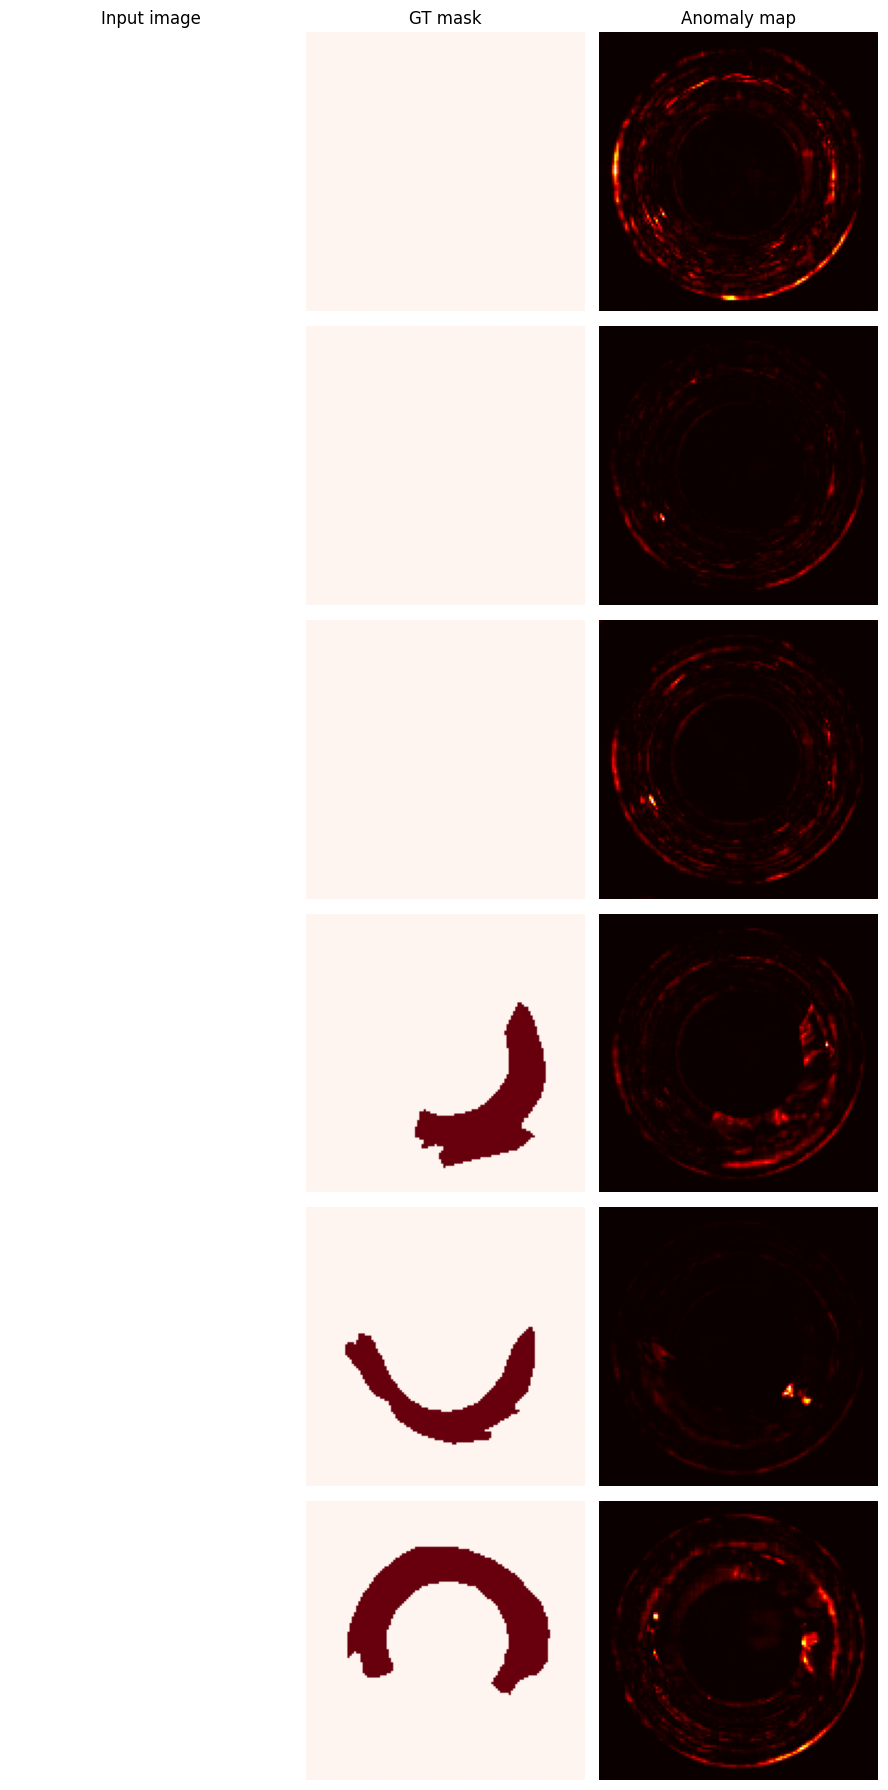

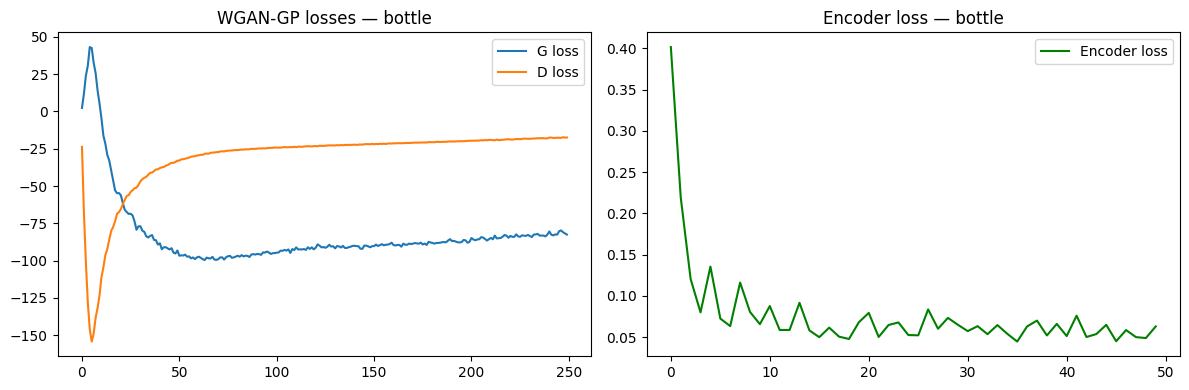


  f-AnoGAN  |  Category: CABLE

Train samples: 224  |  Test samples: 150

[Stage 1] Training WGAN-GP for 250 epochs...
  Epoch  10/250  |  G: -9.7591  D: -54.6526
  Epoch  20/250  |  G: 11.4837  D: -54.5494
  Epoch  30/250  |  G: 16.6220  D: -51.3042
  Epoch  40/250  |  G: 21.9816  D: -49.8392
  Epoch  50/250  |  G: 26.2022  D: -48.8059
  Epoch  60/250  |  G: 29.4834  D: -48.3164
  Epoch  70/250  |  G: 32.6984  D: -48.2259
  Epoch  80/250  |  G: 37.9565  D: -49.2704
  Epoch  90/250  |  G: 37.5897  D: -48.4675
  Epoch 100/250  |  G: 40.6933  D: -48.9737
  Epoch 110/250  |  G: 42.2636  D: -49.4787
  Epoch 120/250  |  G: 41.6871  D: -49.3968
  Epoch 130/250  |  G: 41.8981  D: -48.5591
  Epoch 140/250  |  G: 41.3701  D: -49.6757
  Epoch 150/250  |  G: 41.3075  D: -49.4264
  Epoch 160/250  |  G: 42.1088  D: -50.2923
  Epoch 170/250  |  G: 45.8255  D: -49.7826
  Epoch 180/250  |  G: 42.3563  D: -49.4081
  Epoch 190/250  |  G: 44.7265  D: -50.9994
  Epoch 200/250  |  G: 39.7367  D: -48.5017


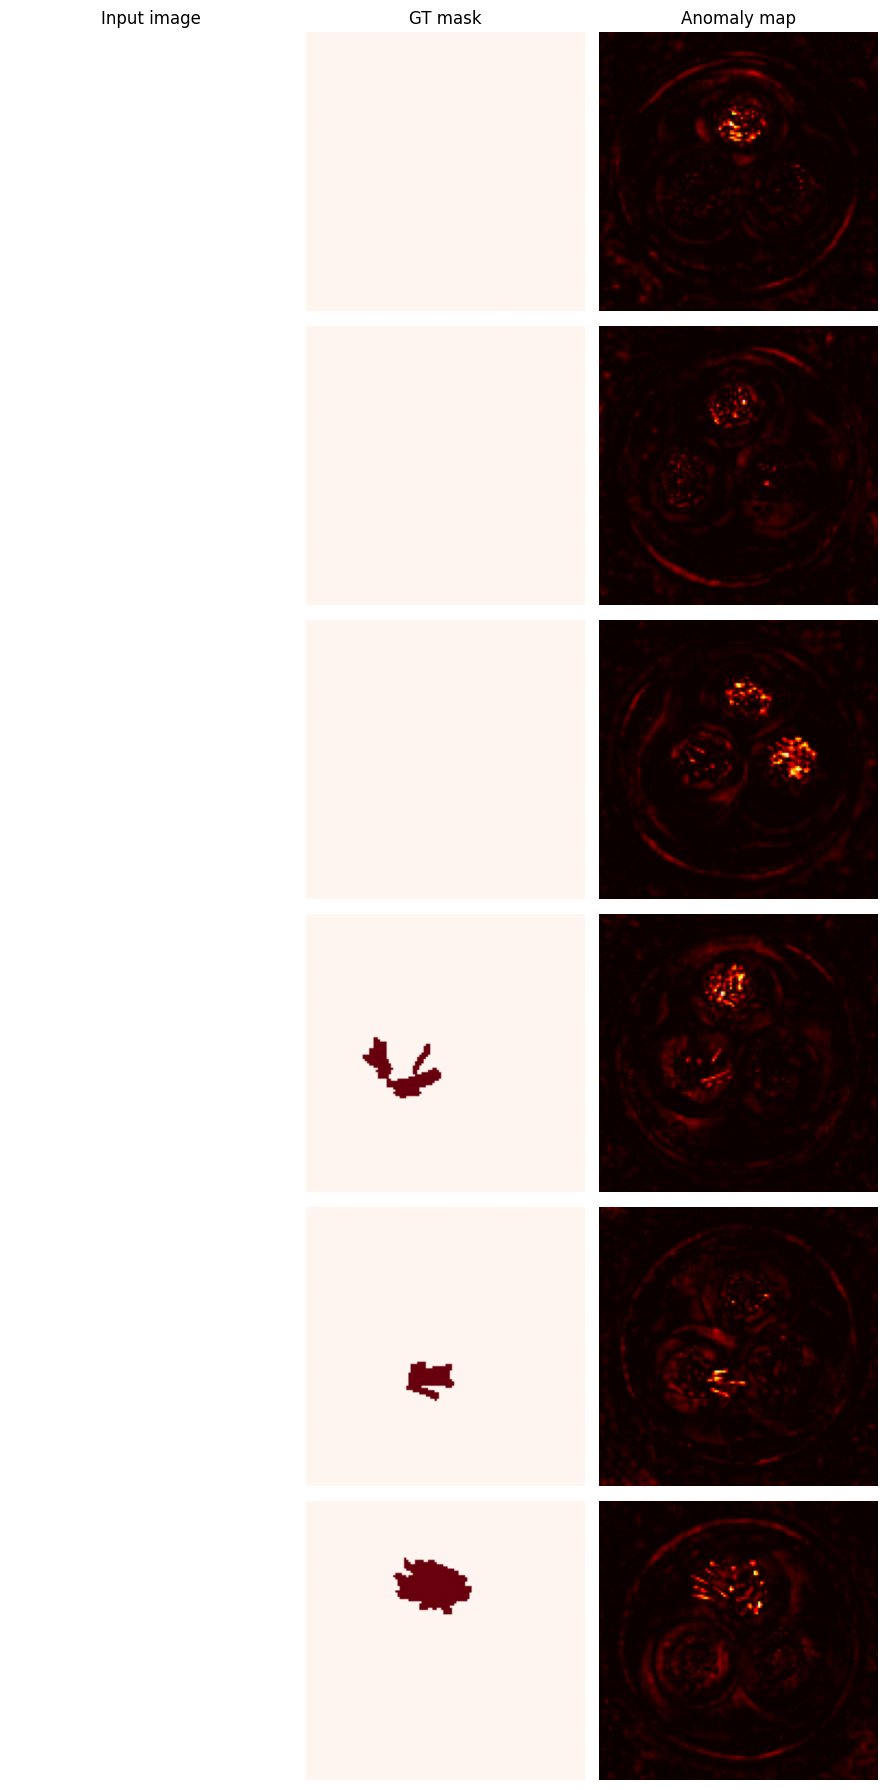

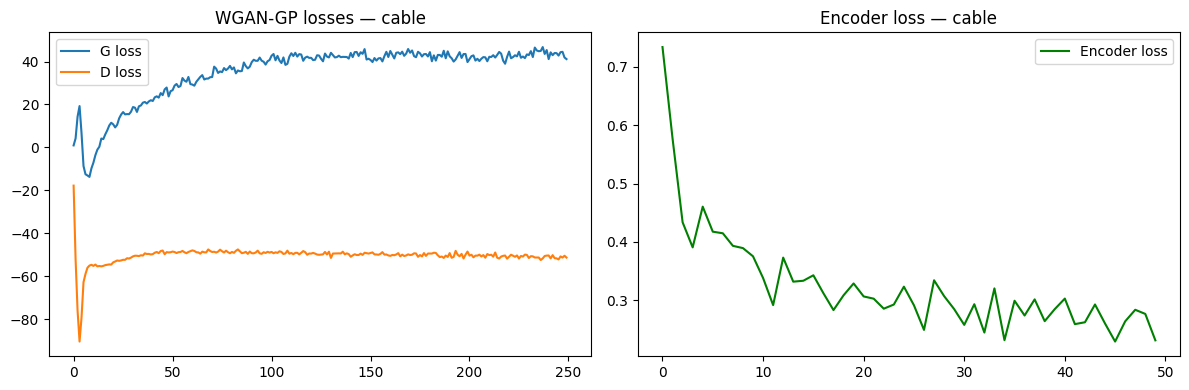


  f-AnoGAN  |  Category: TILE

Train samples: 230  |  Test samples: 117

[Stage 1] Training WGAN-GP for 250 epochs...
  Epoch  10/250  |  G: 15.7521  D: -43.8291
  Epoch  20/250  |  G: 37.4956  D: -52.0488
  Epoch  30/250  |  G: 40.9372  D: -49.1844
  Epoch  40/250  |  G: 35.7581  D: -37.3359
  Epoch  50/250  |  G: 27.3726  D: -31.1880
  Epoch  60/250  |  G: 14.9758  D: -25.9887
  Epoch  70/250  |  G: 15.1417  D: -27.5641
  Epoch  80/250  |  G: 8.5674  D: -32.2793
  Epoch  90/250  |  G: 9.3797  D: -28.1532
  Epoch 100/250  |  G: 11.6668  D: -29.0625
  Epoch 110/250  |  G: 13.0907  D: -29.7927
  Epoch 120/250  |  G: 15.7805  D: -32.7720
  Epoch 130/250  |  G: 12.7155  D: -39.8700
  Epoch 140/250  |  G: 12.6242  D: -41.4533
  Epoch 150/250  |  G: 13.1504  D: -43.8062
  Epoch 160/250  |  G: 10.3335  D: -41.4859
  Epoch 170/250  |  G: 12.1558  D: -41.3373
  Epoch 180/250  |  G: 14.6325  D: -47.0854
  Epoch 190/250  |  G: 14.6343  D: -47.5925
  Epoch 200/250  |  G: 15.4518  D: -45.7797
  E

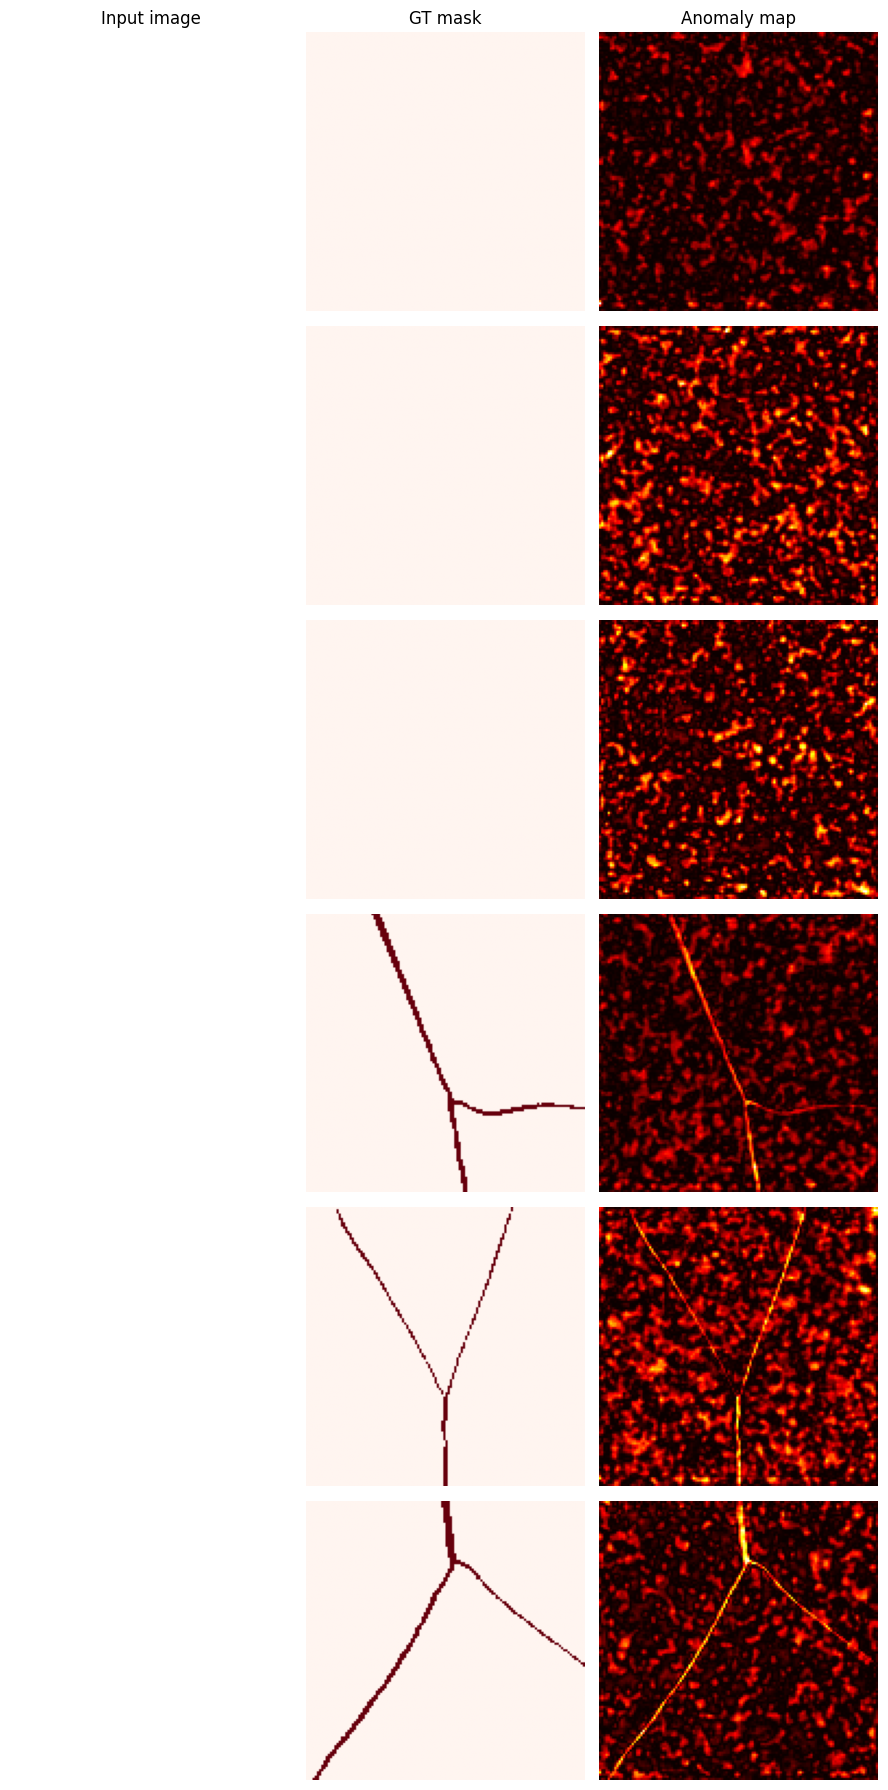

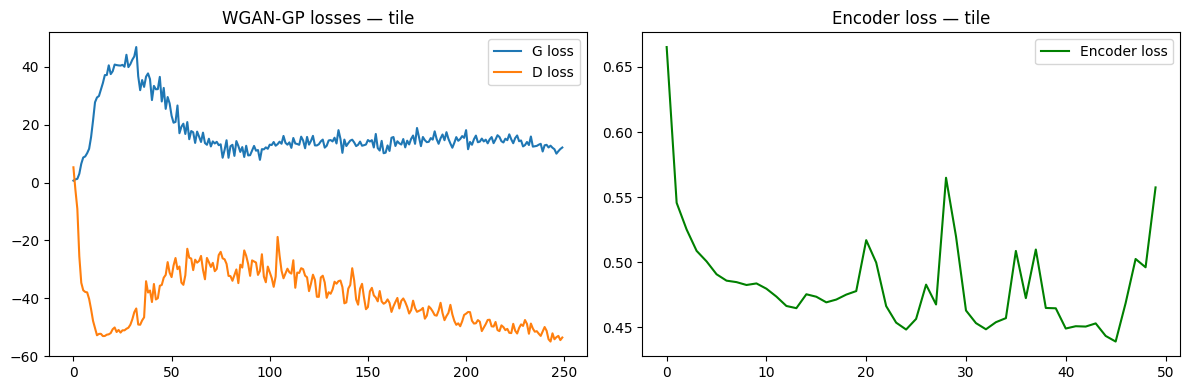

║         f-AnoGAN FINAL RESULTS       ║
║ Category             ║ Img AUROC ║ Pix AUROC ║
║ bottle               ║   90.40%  ║   82.47%  ║
║ cable                ║   77.31%  ║   77.10%  ║
║ tile                 ║   73.05%  ║   55.77%  ║


In [13]:
if __name__ == "__main__":
    all_results = {}
    for cat in ["bottle", "cable", "tile"]:
        result = run_fanogan(category=cat)
        all_results[cat] = result
 

    print("║         f-AnoGAN FINAL RESULTS       ║")

    print("║ Category             ║ Img AUROC ║ Pix AUROC ║")

    for cat, m in all_results.items():
        print(f"║ {cat:<20} ║   {m['img_auroc']*100:.2f}%  ║   {m['pix_auroc']*100:.2f}%  ║")

 
    with open("fanogan_all_results.json", "w") as f:
        json.dump(all_results, f, indent=2)